In [1]:
import re
import textwrap
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import scipy.stats as stats
from langfuse import Langfuse
import matplotlib.pyplot as plt

from polylex_chatbot.env import load_project_env

env_path = load_project_env()

In [2]:
DICT_LABELS = {
    "hit_at_1": "Recall@1",
    "hit_at_2": "Recall@2",
    "hit_at_3": "Recall@3",
    "hit_at_4": "Recall@4",
    "hit_at_5": "Recall@5",
    "hit_at_10": "Recall@10",
    "hit_at_15": "Recall@15",
    "hit_at_20": "Recall@20",
    "Context Relevance (Contextrelevance-Langfuse)": "Context relevance",
    "mrr_doc": "Reciprocal rank",
    "ratio_correct_docs": "Precision",
    "semantic_similarity": "Semantic similarity",
    "len_answers_quality": "Answer lengths comparison",
    "Answer Correctness - RAGAS": "Answer correctness",
    "chrf_score": "Score chrF",
    "Groundedness (Faithfulness-RAGAS)": "Groundedness",
    "Answer Relevance (Relevance-Langfuse)": "Answer relevance"
}

In [3]:
langfuse = Langfuse()
DATASET_NAME = "20250520_clean_dev_dataset"
dataset = langfuse.get_dataset(DATASET_NAME)
RUN_NAME = "20260616_164451_collection_mistralai/Mistral-Small-3.2-24B-Instruct-2506_2026-06-24T13:16:41.964907 - 2026-06-24T11:18:57.160627Z"

In [4]:
run = langfuse.get_dataset_run(
    dataset_name=DATASET_NAME,
    run_name=RUN_NAME
)
collection_name = run.metadata.get("collection_name")
llm_name = run.metadata.get("llm_name").split("/")[1]

In [5]:
experiment_path = Path.cwd() / "rag_experiment"
experiment_path.mkdir(exist_ok=True)

run_path = experiment_path / f"{collection_name}_{llm_name}"
run_path.mkdir(exist_ok=True)

In [6]:
def langfuse_scores_to_df(results):
    rows = []

    for result in results:
        question = result.input.get("query")
        for metric in result.scores:
            rows.append({
                "trace_id": metric.observation_id,
                "question": question,
                "metric": metric.name,
                "value": metric.value
            })

    df_long = pd.DataFrame(rows)

    df_wide = (
        df_long
        .pivot_table(
            index=["trace_id", "question"],
            columns=["metric"],
            values="value",
            aggfunc="first"
        )
        .reset_index()
    )

    df_wide.columns.name = None

    return df_wide

In [7]:
trace_ids = [item.trace_id for item in run.dataset_run_items]
results = [langfuse.api.trace.get(trace_id) for trace_id in trace_ids]
df_scores = langfuse_scores_to_df(results)

ordered_cols = [
    "trace_id",
    "question",
    # retrieval
    "hit_at_1",
    "hit_at_2",
    "hit_at_3",
    "hit_at_4",
    "hit_at_5",
    "hit_at_10",
    "hit_at_15",
    "hit_at_20",
    "Context Relevance (Contextrelevance-Langfuse)", # evaluate if useful context retrieved
    "mrr_doc",
    "ratio_correct_docs",
    # generation (based on ground truth)
    "semantic_similarity",
    "len_answers_quality",
    "Answer Correctness - RAGAS",
    "chrf_score",
    # generation (LLM feeling)
    "Groundedness (Faithfulness-RAGAS)", # evaluate if answer based on context retrieved
    "Answer Relevance (Relevance-Langfuse)" # evaluate if answer is relevant to the question
]

remaining_cols = [col for col in df_scores.columns if col not in ordered_cols]
df_scores_ordered = df_scores[[col for col in ordered_cols if col in df_scores.columns]]

In [10]:
score_columns = df_scores_ordered.drop(columns=["trace_id", "question"])

are_scores_in_range = ((score_columns >= 0) & (score_columns <= 1)).all().all()

if not are_scores_in_range:
    raise ValueError("Scores need to be manually checked!")

In [9]:
df_scores_ordered.loc[df_scores_ordered["trace_id"] == "ec0b9ac77f760564", "Answer Correctness - RAGAS"] = 0.6
df_scores = df_scores_ordered.drop(columns=["trace_id", "question"])
df_scores_ordered

,trace_id,question,hit_at_1,hit_at_2,hit_at_3,hit_at_4,hit_at_5,hit_at_10,hit_at_15,hit_at_20,Context Relevance (Contextrelevance-Langfuse),mrr_doc,ratio_correct_docs,semantic_similarity,len_answers_quality,Answer Correctness - RAGAS,chrf_score,Groundedness (Faithfulness-RAGAS),Answer Relevance (Relevance-Langfuse)
0,0da1537a6882f50c,A combien de semaines de vacances par an ai-je...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.20,0.553124,0.025974,0.950000,0.097032,0.833333,0.90
1,11995e46b1c52808,Les emprunts dans un travail écrit doivent-ils...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.10,0.514758,0.114391,1.000000,0.272652,1.000000,1.00
2,29ec4816e875f688,Quelles sont les conditons de réussite pour un...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.00,0.550782,0.575569,0.000000,0.211584,1.000000,1.00
3,6d71539ea4f1aa87,Est-ce qu'une décision de la Commission des pr...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.20,0.444719,0.272727,0.980000,0.122785,1.000000,1.00
4,a08b4e4e1d82dce3,"J'envisage de commencer mes études à l'EPFL. ""...",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.30,0.813254,0.647059,0.750000,0.258847,1.000000,1.00
5,a1b618dbff8b4c7c,Je suis en première année de bachelor et j'ai ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.000000,0.00,0.865698,0.659218,0.980000,0.406698,1.000000,0.95
6,a37eda42c4ce19e0,"En tant qu’étudiant, puis-je créer un site web...",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.25,0.654360,0.182581,1.000000,0.321807,0.700000,0.30
7,aafe2a5662746683,Est-ce que le COSEC est rattaché à la VPF à l'...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.000000,0.30,0.552560,0.105802,1.000000,0.227293,1.000000,1.00
8,bc19a000c4683085,Est-ce qu'un doctorant peut racheter son ordin...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00,0.663915,0.760192,0.750000,0.374684,0.833333,0.90
9,cc772a1590ececd8,Puis-je être immatriculé dans deux universités...,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.250000,0.05,0.836158,0.367089,0.666667,0.422282,1.000000,1.00


In [11]:
df_scores_ordered_path = run_path / "df_scores_ordered.csv"
df_scores_ordered.to_csv(df_scores_ordered_path, index=False)

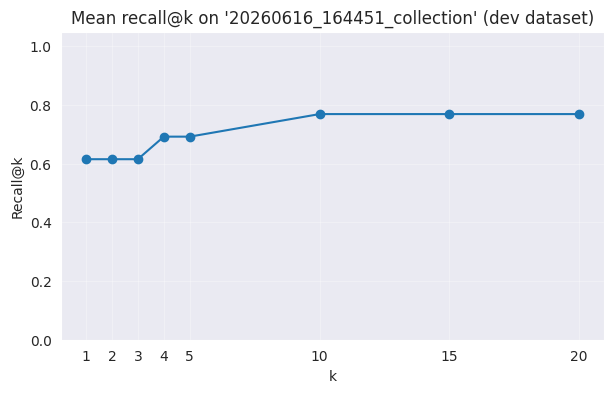

In [12]:
recall_cols = [col for col in df_scores_ordered.columns if re.match(r"^hit_at_\d+$", col)]

recall_df = pd.DataFrame({
    "k": [int(col.split("_")[-1]) for col in recall_cols],
    "mean_recall": [df_scores_ordered[col].mean() for col in recall_cols],
}).sort_values("k")

plt.figure(figsize=(7, 4))
plt.plot(
    recall_df["k"],
    recall_df["mean_recall"],
    marker="o",
)

plt.xlabel("k")
plt.ylabel("Recall@k")
plt.title(f"Mean recall@k on '{collection_name}' (dev dataset)")
plt.xticks(recall_df["k"])
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.savefig(run_path / "mean_recall_at_k.png")
plt.show()

In [13]:
retrieval_scores = df_scores[["mrr_doc", "ratio_correct_docs", "Context Relevance (Contextrelevance-Langfuse)"]]
kendall_matrix_retrieval = retrieval_scores.corr(method="kendall")
kendall_matrix_retrieval

,mrr_doc,ratio_correct_docs,Context Relevance (Contextrelevance-Langfuse)
mrr_doc,1.000000,0.709751,0.478386
ratio_correct_docs,0.709751,1.000000,0.166810
Context Relevance (Contextrelevance-Langfuse),0.478386,0.166810,1.000000


In [14]:
kendall_matrix_retrieval_path = run_path / "kendall_matrix_retrieval.csv"
kendall_matrix_retrieval.to_csv(kendall_matrix_retrieval_path, index=False)

In [15]:
ground_truth_vs_generated_scores = df_scores[["semantic_similarity", "Answer Correctness - RAGAS", "len_answers_quality", "chrf_score"]]
kendall_matrix_ground_truth_vs_generated = ground_truth_vs_generated_scores.corr(method="kendall")
kendall_matrix_ground_truth_vs_generated

,semantic_similarity,Answer Correctness - RAGAS,len_answers_quality,chrf_score
semantic_similarity,1.000000,-0.266880,0.384615,0.461538
Answer Correctness - RAGAS,-0.266880,1.000000,-0.427008,-0.133440
len_answers_quality,0.384615,-0.427008,1.000000,0.410256
chrf_score,0.461538,-0.133440,0.410256,1.000000


In [16]:
kendall_matrix_ground_truth_vs_generated_path = run_path / "kendall_matrix_ground_truth_vs_generated.csv"
kendall_matrix_ground_truth_vs_generated.to_csv(kendall_matrix_ground_truth_vs_generated_path, index=False)

In [17]:
triad_scores = df_scores[["Context Relevance (Contextrelevance-Langfuse)", "Groundedness (Faithfulness-RAGAS)", "Answer Relevance (Relevance-Langfuse)"]]
kendall_matrix_triad = triad_scores.corr(method="kendall")
kendall_matrix_triad

,Context Relevance (Contextrelevance-Langfuse),Groundedness (Faithfulness-RAGAS),Answer Relevance (Relevance-Langfuse)
Context Relevance (Contextrelevance-Langfuse),1.000000,0.055216,0.127515
Groundedness (Faithfulness-RAGAS),0.055216,1.000000,0.625463
Answer Relevance (Relevance-Langfuse),0.127515,0.625463,1.000000


In [18]:
kendall_matrix_triad_path = run_path / "kendall_matrix_triad.csv"
kendall_matrix_triad.to_csv(kendall_matrix_triad_path, index=False)

In [19]:
confidence_level = 0.95
n = len(df_scores)

means = df_scores.mean()
stds = df_scores.std(ddof=1)

ci_lower, ci_upper = stats.t.interval(confidence_level, df=n-1, loc=means, scale=stds/np.sqrt(n))
ci_lower = pd.Series(ci_lower, index=df_scores.columns)
ci_upper = pd.Series(ci_upper, index=df_scores.columns)

df_stats = pd.DataFrame(
    [
        means,
        stds,
        ci_lower,
        ci_upper
    ],
    index=["mean", "standard_deviation", "ci_lower_bound", "ci_upper_bound"]
)

df_stats

,hit_at_1,hit_at_2,hit_at_3,hit_at_4,hit_at_5,hit_at_10,hit_at_15,hit_at_20,Context Relevance (Contextrelevance-Langfuse),mrr_doc,ratio_correct_docs,semantic_similarity,len_answers_quality,Answer Correctness - RAGAS,chrf_score,Groundedness (Faithfulness-RAGAS),Answer Relevance (Relevance-Langfuse)
mean,0.615385,0.615385,0.615385,0.692308,0.692308,0.769231,0.769231,0.769231,0.738462,0.645604,0.146154,0.674207,0.440403,0.667436,0.285804,0.951282,0.896154
standard_deviation,0.506370,0.506370,0.506370,0.480384,0.480384,0.438529,0.438529,0.438529,0.419401,0.471208,0.112660,0.142697,0.319810,0.404313,0.105019,0.097767,0.198391
ci_lower_bound,0.309388,0.309388,0.309388,0.402014,0.402014,0.504230,0.504230,0.504230,0.485020,0.360856,0.078074,0.587976,0.247143,0.423112,0.222341,0.892202,0.776267
ci_upper_bound,0.921381,0.921381,0.921381,0.982601,0.982601,1.034231,1.034231,1.034231,0.991903,0.930352,0.214234,0.760437,0.633662,0.911760,0.349266,1.010362,1.016040


In [20]:
df_stats_path = run_path / "df_stats.csv"
df_stats.to_csv(df_stats_path, index=True)

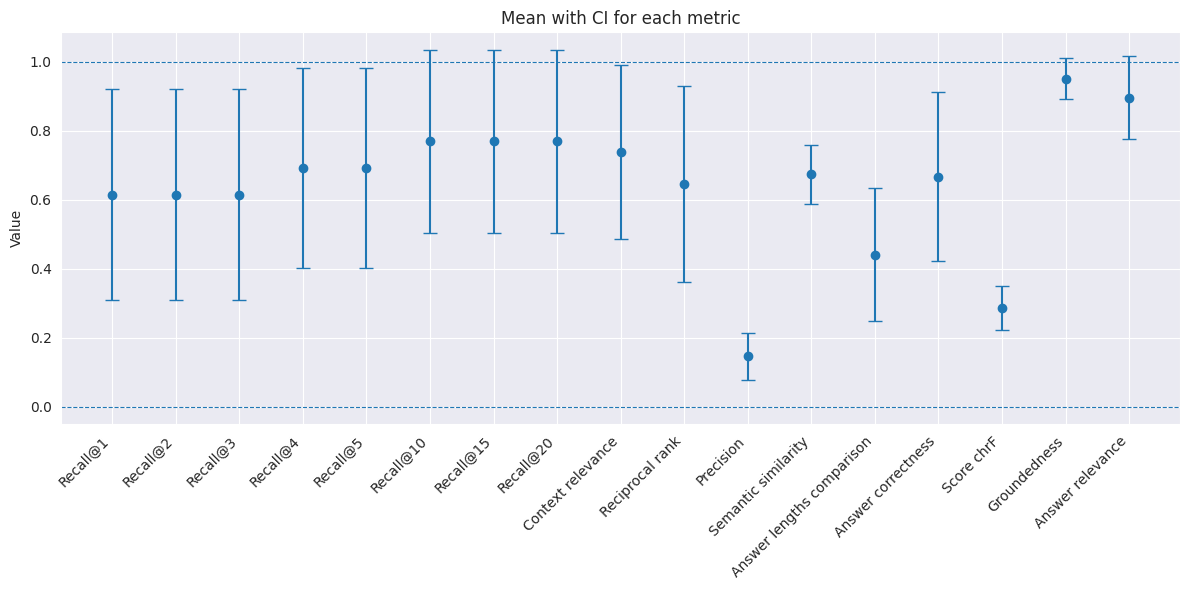

In [21]:
means = df_stats.loc["mean"]
ci_lower = df_stats.loc["ci_lower_bound"]
ci_upper = df_stats.loc["ci_upper_bound"]
yerr_lower = means - ci_lower
yerr_upper = ci_upper - means
x = np.arange(len(df_stats.columns))
x_labels = [DICT_LABELS[col] for col in df_stats.columns]

plt.figure(figsize=(12, 6))
plt.errorbar(x, means.values, yerr=[yerr_lower, yerr_upper], fmt="o", capsize=5, linewidth=1.5)
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Mean with CI for each metric")
plt.axhline(0, linestyle="--", linewidth=0.8)
plt.axhline(1, linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(run_path / "confidence_intervals.png")
plt.show()

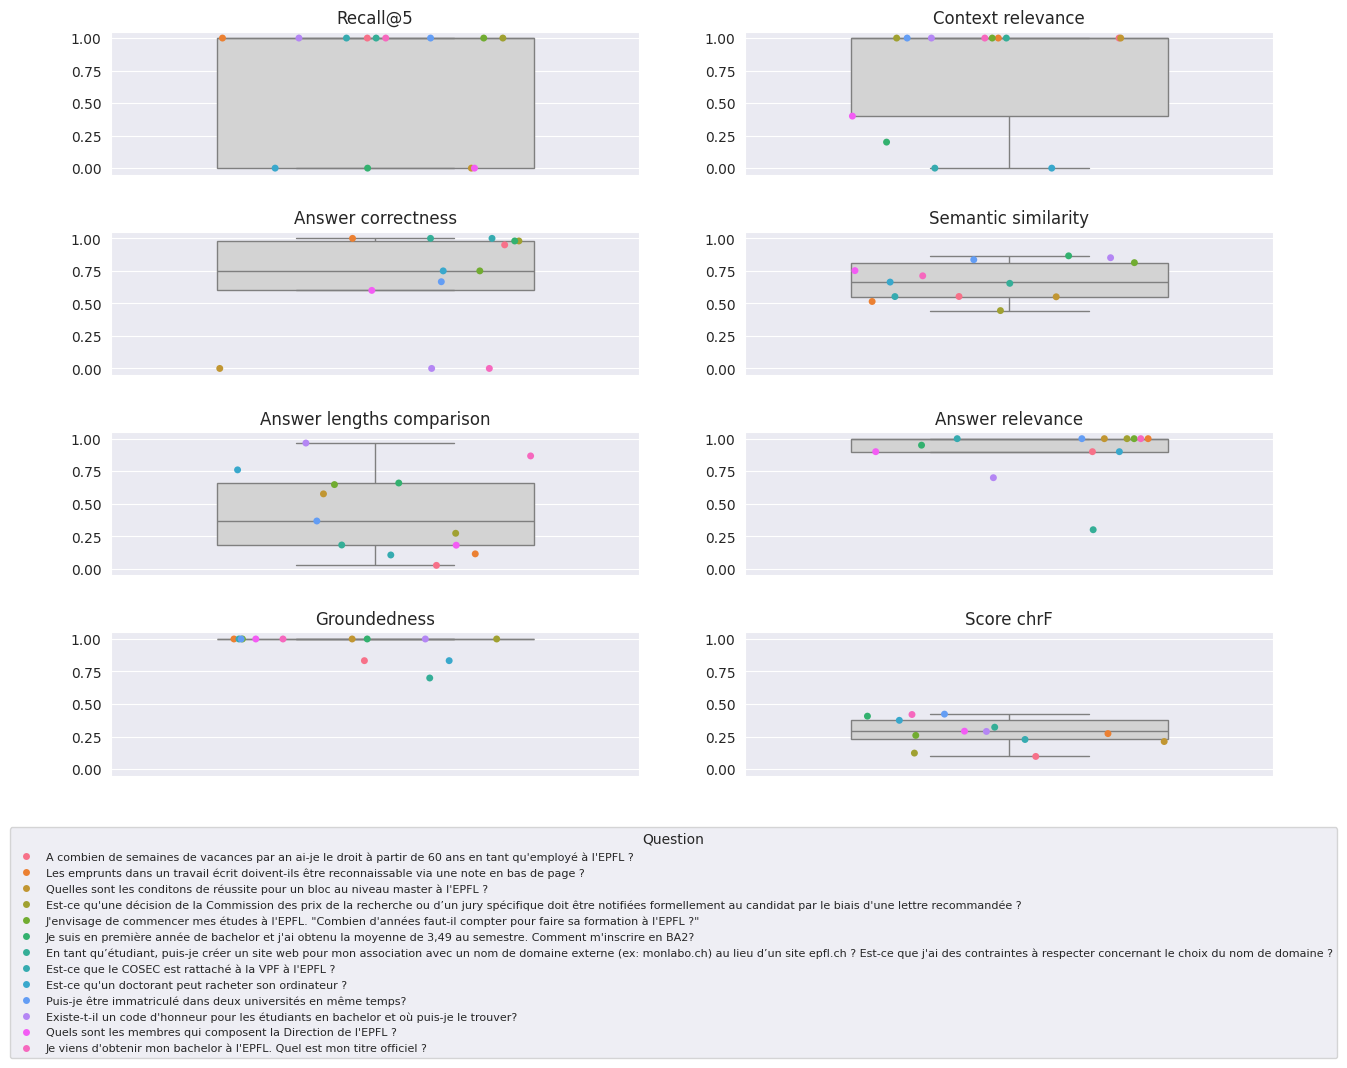

In [24]:
def plot_boxplots_grid(df, cols, dict_labels):
    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    axes = axes.flatten()
    legend_handles = None
    legend_labels = None

    hue_order = pd.unique(df["question"])
    palette = sns.color_palette("husl", n_colors=len(hue_order))

    for ax, col in zip(axes, cols):
        sns.boxplot(data=df, y=col, color="lightgray", showfliers=False, width=0.6, ax=ax)
        sns.stripplot(data=df, y=col, hue="question", hue_order=hue_order, palette=palette, jitter=0.3, ax=ax)

        ax.set_title(f"{dict_labels[col]}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_ylim(-0.05, 1.05)

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    for ax in axes[len(cols):]:
        ax.remove()

    fig.subplots_adjust(bottom=0.26, hspace=0.4, wspace=0.2)

    legend_labels = [
        textwrap.fill(label, width=300)
        for label in legend_labels
    ]

    fig.legend(
        legend_handles,
        legend_labels,
        title="Question",
        loc="lower center",
        bbox_to_anchor=(0.05, 0.02, 0.90, 0.22),
        title_fontsize=10,
        fontsize=8
    )

    plt.savefig(run_path / "metric_boxplots.png")

    plt.show()

metrics_to_plot = ["hit_at_5", "Context Relevance (Contextrelevance-Langfuse)",
                   "Answer Correctness - RAGAS", "semantic_similarity",
                   "len_answers_quality", "Answer Relevance (Relevance-Langfuse)",
                   "Groundedness (Faithfulness-RAGAS)", "chrf_score"]

plot_boxplots_grid(df_scores_ordered, metrics_to_plot, DICT_LABELS)

# TODO : dans Langfuse, aller sous Tracing puis Observations et filtrer avec metadata: target_observation_id = trace_id